##  [git repo sunnysavita for classes code](https://github.com/sunnysavita10/Agentic-2.0)

In [2]:
def function1(input1):
    return input1 + " from first function"



In [3]:
def function2(input2):
    return input2 + " from second function"



In [4]:
def function3(input3):
    return input3 + " from third function"

In [5]:
function1("Hello")

'Hello from first function'

In [7]:
function2("Hello")

'Hello from second function'

In [5]:
from langgraph.graph import Graph


In [37]:
workflow = Graph() \
    .add_node("function1", function1) \
    .add_node("function2", function2) \
    .add_node("function3", function3) \
    .add_edge("function1", "function2") \
    .add_edge("function2", "function3")

In [38]:
workflow.set_entry_point("function1")


In [39]:
workflow.set_finish_point("function3")

In [40]:
app=workflow.compile() # This will start the workflow with "Hello" as input to function1

In [41]:
app.get_graph()

Graph(nodes={'function1': Node(id='function1', name='function1', data=function1(tags=None, recurse=True, explode_args=False, func_accepts_config=False, func_accepts={}), metadata=None), 'function2': Node(id='function2', name='function2', data=function2(tags=None, recurse=True, explode_args=False, func_accepts_config=False, func_accepts={}), metadata=None), 'function3': Node(id='function3', name='function3', data=function3(tags=None, recurse=True, explode_args=False, func_accepts_config=False, func_accepts={}), metadata=None), '__start__': Node(id='__start__', name='__start__', data=None, metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='function1', data=None, conditional=False), Edge(source='function1', target='function2', data=None, conditional=False), Edge(source='function2', target='function3', data=None, conditional=False), Edge(source='function3', target='__end__', data=None, conditional=False)])

In [35]:
from IPython.display import Image, display

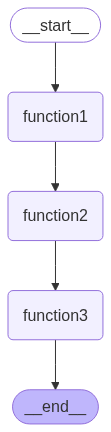

In [42]:
display(Image(app.get_graph().draw_mermaid_png()))

In [43]:
app.invoke("hi this is sunny")

'hi this is sunny from first function from second function from third function'

In [ ]:
workflow1 = Graph(
    start="function1",
    functions={
        "function1": function1,
        "function2": function2,
        "function3": function3,
    },
    edges={
        "function1": ["function2"],
        "function2": ["function3"],
    },
)
function3("Hello")

to see the output from each function

In [45]:
for output in app.stream("hi this is sunny"):
    print(output)
    print("_"*80)
print("Workflow completed successfully.")

{'function1': 'hi this is sunny from first function'}
________________________________________________________________________________
{'function2': 'hi this is sunny from first function from second function'}
________________________________________________________________________________
{'function3': 'hi this is sunny from first function from second function from third function'}
________________________________________________________________________________
Workflow completed successfully.


In [ ]:
def llm1(input):
    return f"LLM response to: {input}"

In [23]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-1.5-flash")


In [24]:
response = llm.invoke("What is the capital of France?")
print(response)

content='Paris' additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-1.5-flash', 'safety_ratings': []} id='run--7717c1f5-3aab-4e5a-a875-b8a8fa860506-0' usage_metadata={'input_tokens': 7, 'output_tokens': 2, 'total_tokens': 9, 'input_token_details': {'cache_read': 0}}


Bad pipe message: %s [b'\xfa\xf4\xa90\x1c\xbd\xa9\x18\x08ew\xc2\xc3\x14c`\x7f\xd9\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00\x87\x00\x88\x00\x89\x00\x96\x00\x97\x00\x98\x00\x99\x00\x9a\x00\x9b\x00\x9c\x00\x9d\x00\x9e\x00\x9f\x00\xa0\x00\xa1\x00\xa2\x00\xa3\x00\xa4\x00\xa5\x00\xa6\x00\xa7\x00\xba\x00\xbb\x00\xbc\x00\xbd\x00\xbe\x00\xbf\x00\xc0\x00\xc1\x00\xc2\x00\xc3\x00\xc4\x00\xc5\x13\x01\x13\x02\x13\x03\x13\x04\x13\x05\xc0\x01\xc0\x02\xc0\x03\xc0\x04\xc0\x05\xc0\x06']
Bad pipe message: %s [b"\xc0\x08\xc0\t\xc0\n\xc0\x0b\xc0\x0c\xc0\r\xc0\x0e\xc0\x0f\xc0\x10\xc0\x11\xc0\x12\xc0\x13\xc0\x14\xc0\x15\xc0\x16\xc0\x17\xc0\x18\xc0

In [11]:
def llm(input):
    from langchain_google_genai import ChatGoogleGenerativeAI
    model=ChatGoogleGenerativeAI(model='gemini-1.5-flash')
    output=model.invoke(input)
    return output.content

In [12]:
def token_counter(input):
    return len(input.split())

In [10]:
wf1 = Graph()

In [13]:
wf1.add_node("llm", llm)
wf1.add_node("token_counter", token_counter)
wf1.add_edge("llm", "token_counter")

In [14]:
wf1.set_entry_point("llm")
wf1.set_finish_point("token_counter")

In [15]:
app = wf1.compile()

In [19]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_APPLICATION_CREDENTIALS"]  = "/Users/jatinder.singh/drive/office-work/gcpdp-od-qna-embeddings/service_account.json"

In [ ]:



app.get_graph()
app.get_graph().draw_mermaid_png()


b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x00\x93\x00\x00\x01M\x08\x02\x00\x00\x00\x8b\xc4\xca\xa9\x00\x00\x10\x00IDATx\x9c\xec\x9d\t\\T\xd5\xfe\xc0\xcf0;\xc3,\xec\xeb\xb0\x18\x8a+\x81\x80\xe1\x96\x1a\x8a\xb8\x9b\x9a\x1b\xe5\xd2\xa2\x96\xd5\xb3\x9e\xe9S[\xb4l1M}\xaf\xb2,\xb5\xbfK\xa9\xf5J{b*\xb9/EJ`\xa2\x88\x80\x08\xc8\xee0\xc30\xfb\xca\xff\x07\xf3\x1e\x8f\x97\xa3\xbe|\x9ca\xce\xe5|?\xf3\x99\xcf\xdd\xe6\xce\xbd\xf7{\xcf9\xbfs\xef\xb9\xe7r\x9a\x9a\x9a\x10\x85@8\x88B&\xd4\x1c\xa9Ps\xa4B\xcd\x91\n5G*\xd4\x1c\xa9t\xa49\xa3\xceVw\xd3d\xd0\xd9`\xc0d\xb0#"\xaa\',\xc4\x17z\x08Dl\xa1\x88\x1d \xe7\xc3\x00\xea X\xae\xaf\xcf\xe9\xd4\xd6\x82\x0b\x9a\x92\xcb:e\xb5)0B\x00\x87@\xd0\xf2a\xb1\x90\xfb\x03G\xcb\xd8r\xaa\xc1\tWSf\xf4\r\xe6w\xe9-\xea\x9e$\x16I]\x9d\x06\\m\xeeB\xa62\xe7xCdO\xcf\xae}\xc5\xb0\xcf\x88dl\x96\xa6\xb2\xab\xfa\xc2\x1cMY\x81.!\xc5\'q\x847r!\xae3W]b\xcc\xdcU\x13\xd2E\xf8\xd0h_\x89\x0f\xa3\xcaW\xb5\xc2\x92\xf5C}M\xa91\xf5\xf1\xa0\xe0.\x02\xe4\x12\\d.?\xab1\xfbGe\xda\xec\xe0\x80p>b

In [20]:
app.invoke("This is a test input for the token counter function.")

31

In [21]:
for output in app.stream("This is a test input for the token counter function."):
    print(output)
    print("_"*80)
print("Workflow completed successfully.")

{'llm': "Okay, I understand.  Please provide the input you'd like me to use for testing a token counter function.  I need the actual text or data you want to be analyzed."}
________________________________________________________________________________
{'token_counter': 30}
________________________________________________________________________________
Workflow completed successfully.


END OF DAY 9: INTRODUCTION TO LANGGRAPH COMPLETED WITH GRAPH FLOW AND STEAM TO SEE INDIVIDUAL FUNCTION OUTPUT WITH SAME EXAMPLE TO COUNT THE OUTPUT WORDS FROM LLM FOR A QUERY